<a href="https://colab.research.google.com/github/MarcosJps/Consumo-de-Energia-e-Sustentabilidade/blob/main/Gest%C3%A3o_de_Energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 Segmentação de Consumo de Energia e Sustentabilidade

## 1. Introdução e Compreensão do Problema

### 🎯 Objetivo do Projeto

Este projeto faz parte da avaliação A3 da disciplina de Inteligência Artificial e tem como objetivo desenvolver uma aplicação que **segmenta o consumo de energia elétrica** de clientes de uma região, identificando diferentes perfis de uso e propondo **estratégias de redução de consumo e sustentabilidade**.

### ❓ Qual o Problema que Estamos Resolvendo?

As empresas de energia elétrica enfrentam um grande desafio: como ajudar os clientes a **reduzir o consumo** sem precisar visitar cada casa individualmente?

Com a análise de dados, podemos:
- Identificar **grupos de clientes** com comportamentos parecidos
- Descobrir **anomalias** (clientes que gastam muito mais que o normal)
- Criar **campanhas personalizadas** para cada tipo de cliente
- Promover o uso de **energia renovável** (como painéis solares)

### 📊 O Dataset

Utilizamos o **Household Electric Power Consumption Dataset**, que contém medições de consumo de energia elétrica de uma residência a cada minuto, durante quase 4 anos.

**Variáveis utilizadas:**
| Variável | Descrição | Uso no Projeto |
|:---|:---|:---|
| `Global_active_power` | Consumo total da casa (kW) | Principal métrica de consumo |
| `Sub_metering_1` | Consumo da cozinha (kW) | Identifica uso de eletrodomésticos |
| `Sub_metering_2` | Consumo da lavanderia (kW) | Identifica uso de máquinas |
| `Sub_metering_3` | Consumo de ar-condicionado/aquecedor (kW) | Maior impacto no consumo |
| `Time` | Horário da medição | Permite classificar período do dia |

### 🔧 Algoritmos Utilizados

| Algoritmo | Tipo | Função no Projeto |
|:---|:---|:---|
| **K-Means** | Agrupamento (Clustering) | Segmentar clientes em perfis de consumo |
| **DBSCAN** | Agrupamento com Detecção de Ruído | Identificar anomalias e desperdícios |

### 📋 Etapas do Projeto

1. **Carga e amostragem** dos dados (15.000 registros)
2. **Pré-processamento** com Feature Engineering e Padronização
3. **Segmentação** com K-Means (dashboard interativo)
4. **Detecção de anomalias** com DBSCAN
5. **Avaliação** por métricas (Silhouette Score)
6. **Comparação** entre os algoritmos
7. **Estratégia** de sustentabilidade baseada nos resultados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display
from google.colab import drive
from collections import Counter

drive.mount('/content/drive')

caminho_arquivo = '/content/drive/MyDrive/household_power_consumption.txt'
df = pd.read_csv(caminho_arquivo, sep=';', na_values='?', low_memory=False)

df = df.dropna()
df_amostra = df.sample(n=15000, random_state=42).copy()

Mounted at /content/drive


## 2. Pré-Processamento e Feature Engineering

### 🔧 O que é Pré-Processamento?

Antes de aplicar os algoritmos de Machine Learning, precisamos "limpar" e "organizar" os dados. É como organizar uma planilha bagunçada antes de fazer uma análise séria.

### 📋 Etapas do Pré-Processamento

#### Etapa 1: Feature Engineering (Engenharia de Recursos)

Criamos uma nova variável chamada **"Período"** a partir da coluna de horário (`Time`). Isso ajuda o algoritmo a entender em qual parte do dia o consumo acontece.

**Lógica de classificação:**

| Horário | Período |
|:---|:---|
| 06:00 às 11:59 | ☀️ Manhã |
| 12:00 às 17:59 | 🌤️ Tarde |
| 18:00 às 23:59 | 🌙 Noite |
| 00:00 às 05:59 | 🌑 Madrugada |

**Resultado:** A amostra ficou bem equilibrada entre os 4 períodos, com aproximadamente 3.700 registros em cada um.

#### Etapa 2: One-Hot Encoding

Os algoritmos de Machine Learning **não entendem texto** (como "Manhã", "Tarde"), apenas números.

O **One-Hot Encoding** transforma cada período em colunas numéricas (0 ou 1):

| Período Original | Madrugada | Manhã | Tarde | Noite |
|:---|:---:|:---:|:---:|:---:|
| Manhã | 0 | 1 | 0 | 0 |
| Noite | 0 | 0 | 0 | 1 |
| Madrugada | 1 | 0 | 0 | 0 |

#### Etapa 3: Padronização (StandardScaler)

As variáveis numéricas têm **escalas diferentes**:
- `Global_active_power`: valores entre 0 e 11 kW
- `Sub_metering_3`: valores entre 0 e 31 kW

Se não padronizarmos, o algoritmo dará mais importância para os números maiores. A **padronização** coloca todas as variáveis na mesma escala (média = 0, desvio padrão = 1).

### 📊 Resultado Final do Pré-Processamento

A matriz final de features ficou com:
- **15.000 linhas** (registros da amostra)
- **8 colunas** (4 variáveis numéricas + 4 variáveis de período codificadas)
- Todos os dados **padronizados** e prontos para os algoritmos

In [ ]:
# ==========================================
# 2. PRÉ-PROCESSAMENTO E FEATURE ENGINEERING
# ==========================================

def classificar_periodo(hora_string):
    """Classifica o período do dia com base na hora"""
    # Divide a string "hh:mm:ss" e pega a primeira parte (hora)
    hora = int(hora_string.split(':')[0])

    if hora >= 6 and hora < 12:
        return 'Manha'
    elif hora >= 12 and hora < 18:
        return 'Tarde'
    elif hora >= 18 and hora < 24:
        return 'Noite'
    else:
        return 'Madrugada'

print("🔄 Criando feature de período do dia...")

# Aplica a função para criar a coluna 'Periodo'
df_amostra['Periodo'] = df_amostra['Time'].apply(classificar_periodo)

# Exibe o resultado de forma bonita
print("\n✅ Exemplo de classificação dos períodos do dia:")
print(df_amostra[['Time', 'Periodo']].head(10).to_string(index=False))

# Verifica quantos de cada período foram classificados
print("\n📊 Distribuição dos períodos na amostra:")
print(df_amostra['Periodo'].value_counts())

# ==========================================
# ONE-HOT ENCODING (Converte categorias em números)
# ==========================================
print("\n🔄 Aplicando One-Hot Encoding nos períodos...")

df_onehot = pd.get_dummies(df_amostra[['Periodo']], dtype=int)

# ==========================================
# SELEÇÃO DAS FEATURES NUMÉRICAS
# ==========================================
X_base = df_amostra[['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']]

# Junta as variáveis numéricas com as codificadas (One-Hot)
X_completo = pd.concat([X_base, df_onehot], axis=1)

print(f"✅ Shape final da matriz de features: {X_completo.shape}")
print(f"   - {X_base.shape[1]} variáveis numéricas de consumo")
print(f"   - {df_onehot.shape[1]} variáveis codificadas de período")

# ==========================================
# PADRONIZAÇÃO (Obrigatório para K-Means e DBSCAN)
# ==========================================
print("\n🔄 Padronizando os dados...")

scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X_completo)

print("✅ Padronização concluída com sucesso!")

🔄 Criando feature de período do dia...

✅ Exemplo de classificação dos períodos do dia:
    Time   Periodo
09:44:00     Manha
23:39:00     Noite
17:01:00     Tarde
05:53:00 Madrugada
02:57:00 Madrugada
16:36:00     Tarde
17:48:00     Tarde
18:46:00     Noite
15:25:00     Tarde
22:31:00     Noite

📊 Distribuição dos períodos na amostra:
Periodo
Madrugada    3835
Tarde        3790
Noite        3694
Manha        3681
Name: count, dtype: int64

🔄 Aplicando One-Hot Encoding nos períodos...
✅ Shape final da matriz de features: (15000, 8)
   - 4 variáveis numéricas de consumo
   - 4 variáveis codificadas de período

🔄 Padronizando os dados...
✅ Padronização concluída com sucesso!


## 3. Algoritmos de Agrupamento Utilizados

### 🤖 O que são Algoritmos de Agrupamento?

Algoritmos de agrupamento (clustering) são técnicas de Machine Learning que **agrupam dados parecidos** sem precisar de exemplos prévios. É como separar frutas em grupos por cor e tamanho, sem nunca ter visto uma fruta antes.

Neste projeto, utilizamos **dois algoritmos complementares**:

---

### 🔵 K-Means Clustering

**Como funciona (explicação simples):**

Imagine que você é um professor e precisa dividir 30 alunos em 3 equipes. O K-Means faz assim:

1. 🎯 **Escolhe** 3 alunos aleatórios como "líderes" iniciais
2. 📏 **Mede** a distância de cada aluno até cada líder
3. 👥 **Coloca** cada aluno na equipe do líder mais próximo
4. 🔄 **Recalcula** a posição do líder (média do grupo)
5. 🔁 **Repete** até os grupos ficarem estáveis

**Por que usamos K-Means neste projeto:**
- Cria **perfis de consumo** claros para cada tipo de cliente
- Permite **campanhas personalizadas** por grupo
- Fácil de interpretar e explicar para gestores

**Parâmetro importante:** O número `k` (quantidade de grupos), que pode ser ajustado no dashboard interativo.

---

### 🟠 DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

**Como funciona (explicação simples):**

Imagine uma festa. O DBSCAN funciona assim:

1. 👀 **Olha** para cada pessoa na festa
2. 🔍 **Conta** quantos amigos estão num raio de 2 metros dela
3. ✅ Se tem **muitos amigos** por perto → forma um **grupo**
4. ❌ Se tem **poucos amigos** por perto → é considerado **ruído** (outlier)

**Por que usamos DBSCAN neste projeto:**
- **Detecta anomalias** automaticamente (clientes com consumo estranho)
- Não precisa definir o número de grupos antes
- Identifica desperdícios e possíveis fraudes

**Parâmetros importantes:**
- `eps`: O "raio de amizade" (quão perto os pontos precisam estar)
- `min_samples`: Quantos "amigos" mínimos para formar um grupo

---

### ⚖️ Resumo: Quando usar cada um?

| Situação | Algoritmo Ideal |
|:---|:---|
| Criar campanhas de marketing por perfil | 🔵 K-Means |
| Encontrar clientes com consumo suspeito | 🟠 DBSCAN |
| Dividir todos os clientes em grupos | 🔵 K-Means |
| Identificar desperdícios e fraudes | 🟠 DBSCAN |

📈 CALCULANDO O MÉTODO DO COTOVELO...
(Ajuda a escolher o melhor número de grupos k)


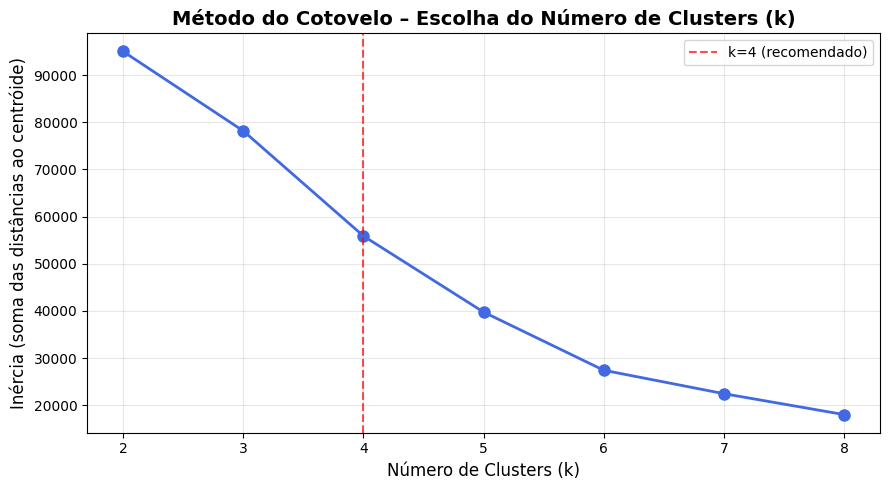


💡 INTERPRETAÇÃO:
   O 'cotovelo' do gráfico indica o ponto onde aumentar k
   deixa de trazer ganho significativo de qualidade.
   → k=4 é o valor recomendado para este dataset.


In [ ]:
# ==========================================
# 3.1 MÉTODO DO COTOVELO (Elbow Method)
# ==========================================

print("📈 CALCULANDO O MÉTODO DO COTOVELO...")
print("(Ajuda a escolher o melhor número de grupos k)")

inertias = []
k_valores = range(2, 9)

for k in k_valores:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_padronizado)
    inertias.append(kmeans.inertia_)

# Gráfico do cotovelo
plt.figure(figsize=(9, 5))
plt.plot(k_valores, inertias, marker='o', color='royalblue', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (recomendado)')
plt.title('Método do Cotovelo – Escolha do Número de Clusters (k)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inércia (soma das distâncias ao centróide)', fontsize=12)
plt.xticks(k_valores)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 INTERPRETAÇÃO:")
print("   O 'cotovelo' do gráfico indica o ponto onde aumentar k")
print("   deixa de trazer ganho significativo de qualidade.")
print("   → k=4 é o valor recomendado para este dataset.")

In [ ]:
# ==========================================
# 4. DASHBOARD INTERATIVO - K-MEANS
# ==========================================

def dashboard_kmeans(k):
    """
    Função interativa que permite visualizar a segmentação
    com diferentes números de grupos (k)
    """
    # Treina o K-Means com o número de grupos escolhido
    kmeans_int = KMeans(n_clusters=k, random_state=42, n_init=10)
    df_amostra['Grupo_Int'] = kmeans_int.fit_predict(X_padronizado)

    # Cria o gráfico de dispersão
    plt.figure(figsize=(12, 7))
    sns.scatterplot(
        x=df_amostra['Global_active_power'],
        y=df_amostra['Sub_metering_3'],
        hue=df_amostra['Grupo_Int'],
        palette='tab10',
        alpha=0.6,
        s=30
    )
    plt.title(f'Segmentação de Clientes - {k} Perfis de Consumo', fontsize=16, fontweight='bold')
    plt.xlabel('Consumo Total da Casa (kWh)', fontsize=12)
    plt.ylabel('Consumo de Ar-Condicionado/Aquecedor (kWh)', fontsize=12)
    plt.legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Exibe as médias de consumo por grupo
    colunas_exibir = ['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
    medias = df_amostra.groupby('Grupo_Int')[colunas_exibir].mean().round(2)

    # Renomeia as colunas para ficar mais intuitivo
    medias = medias.rename(columns={
        'Global_active_power': '⚡ Consumo Total',
        'Sub_metering_1': '🍳 Cozinha',
        'Sub_metering_2': '🧺 Lavanderia',
        'Sub_metering_3': '❄️ Ar-Condicionado'
    })

    print(f"\n📊 MÉDIAS DE CONSUMO POR GRUPO (k={k}):")
    print("=" * 50)
    display(medias)

    # Interpretação rápida
    print("\n💡 INTERPRETAÇÃO:")
    print("-" * 50)

    # Identifica o grupo com maior consumo de ar-condicionado
    grupo_ar = medias['❄️ Ar-Condicionado'].idxmax()
    print(f"✅ Grupo {grupo_ar} tem o maior consumo de Ar-Condicionado")

    # Identifica o grupo com menor consumo total
    grupo_economico = medias['⚡ Consumo Total'].idxmin()
    print(f"✅ Grupo {grupo_economico} é o mais econômico (baixo consumo total)")

# Executa o dashboard interativo
print("\n🎮 DASHBOARD INTERATIVO")
print("=" * 50)
print("Use o controle deslizante abaixo para testar diferentes números de grupos (k)")
print("-" * 50)

interact(dashboard_kmeans, k=widgets.IntSlider(
    min=2,
    max=6,
    step=1,
    value=4,
    description='📊 Nº Grupos:',
    style={'description_width': 'initial'}
));


🎮 DASHBOARD INTERATIVO
Use o controle deslizante abaixo para testar diferentes números de grupos (k)
--------------------------------------------------


interactive(children=(IntSlider(value=4, description='📊 Nº Grupos:', max=6, min=2, style=SliderStyle(descripti…

## 4. Visualização Interativa dos Resultados (K-Means)

### 🎮 Dashboard Interativo

Criamos um **dashboard interativo** que permite explorar a segmentação dos clientes em tempo real. Você pode ajustar o número de grupos (k) usando o controle deslizante e ver como os clientes são reorganizados instantaneamente.

### 📊 O que o Gráfico Mostra?

O gráfico de dispersão cruza duas informações importantes:

- **Eixo X:** Consumo Total da Casa (kW)
- **Eixo Y:** Consumo de Ar-Condicionado/Aquecedor (kW)

Cada **cor** representa um grupo diferente de clientes, identificado pelo K-Means.

### 🔍 Como Interpretar os Grupos

Com base nas médias de consumo, podemos dar "nomes" aos grupos:

| Grupo | Característica Principal | Estratégia Sugerida |
|:---|:---|:---|
| **Grupo Econômico** | Baixo consumo em todas as categorias | Programa de fidelidade e engajamento |
| **Grupo Ar-Condicionado** | Alto consumo de ar-condicionado | Campanha de energia solar |
| **Grupo Cozinha/Lavanderia** | Alto consumo de eletrodomésticos | Troca por aparelhos eficientes (Selo Procel) |

### 💡 Dica de Uso

Experimente testar diferentes valores de **k** (de 2 a 6) no controle deslizante e observe:

- **k=2**: Separação mais simples (alto vs baixo consumo)
- **k=3 ou k=4**: Melhor equilíbrio entre detalhamento e simplicidade
- **k=5 ou k=6**: Grupos mais específicos, mas podem ser difíceis de interpretar

A **nota do Silhouette Score** ajuda a decidir qual k é melhor (quanto mais próximo de 1.0, melhor).

In [ ]:
# ==========================================
# 5. APLICAÇÃO DO DBSCAN
# ==========================================

print("🔄 Rodando o DBSCAN...")
print("(Testando diferentes configurações para encontrar a melhor)")

# --- TESTE 1: Parâmetros mais "relaxados" ---
print("\n--- Teste 1: eps=2.0, min_samples=50 ---")
dbscan1 = DBSCAN(eps=2.0, min_samples=50)
labels1 = dbscan1.fit_predict(X_padronizado)
grupos1 = Counter(labels1)
print(f"Grupos encontrados: {len(set(labels1)) - (1 if -1 in labels1 else 0)}")
print(f"Pontos de ruído: {grupos1.get(-1, 0)}")

# --- TESTE 2: Mais relaxado ainda ---
print("\n--- Teste 2: eps=2.5, min_samples=100 ---")
dbscan2 = DBSCAN(eps=2.5, min_samples=100)
labels2 = dbscan2.fit_predict(X_padronizado)
grupos2 = Counter(labels2)
print(f"Grupos encontrados: {len(set(labels2)) - (1 if -1 in labels2 else 0)}")
print(f"Pontos de ruído: {grupos2.get(-1, 0)}")

# --- TESTE 3: Meio termo ---
print("\n--- Teste 3: eps=1.8, min_samples=80 ---")
dbscan3 = DBSCAN(eps=1.8, min_samples=80)
labels3 = dbscan3.fit_predict(X_padronizado)
grupos3 = Counter(labels3)
print(f"Grupos encontrados: {len(set(labels3)) - (1 if -1 in labels3 else 0)}")
print(f"Pontos de ruído: {grupos3.get(-1, 0)}")

# --- ESCOLHE O MELHOR RESULTADO ---
# Vamos usar o Teste 2 (mais simples, menos grupos)
df_amostra['Grupo_DBSCAN'] = labels2

print("\n" + "="*50)
print("📊 RESULTADO FINAL DO DBSCAN (Teste 2 escolhido):")

for grupo, quantidade in sorted(Counter(labels2).items()):
    if grupo == -1:
        print(f"   ➥ Ruído (anomalias): {quantidade} pontos")
    else:
        print(f"   ➥ Grupo {grupo}: {quantidade} pontos")

# Separa normais e anormais
df_ruido = df_amostra[df_amostra['Grupo_DBSCAN'] == -1]
df_normal = df_amostra[df_amostra['Grupo_DBSCAN'] != -1]

print(f"\n💡 INTERPRETAÇÃO:")
print(f"   - Clientes com consumo NORMAL: {len(df_normal)}")
print(f"   - Clientes com consumo ANORMAL (ruído): {len(df_ruido)}")
print(f"   - Porcentagem de anomalias: {len(df_ruido)/len(df_amostra)*100:.1f}%")

# Comparação entre normais e anormais
print(f"\n🔍 COMPARAÇÃO DE CONSUMO MÉDIO:")
print(f"\n   CLIENTES ANORMAIS (possíveis problemas):")
print(f"   - Consumo Total: {df_ruido['Global_active_power'].mean():.2f} kW")
print(f"   - Cozinha: {df_ruido['Sub_metering_1'].mean():.2f} kW")
print(f"   - Lavanderia: {df_ruido['Sub_metering_2'].mean():.2f} kW")
print(f"   - Ar-Condicionado: {df_ruido['Sub_metering_3'].mean():.2f} kW")

print(f"\n   CLIENTES NORMAIS:")
print(f"   - Consumo Total: {df_normal['Global_active_power'].mean():.2f} kW")
print(f"   - Cozinha: {df_normal['Sub_metering_1'].mean():.2f} kW")
print(f"   - Lavanderia: {df_normal['Sub_metering_2'].mean():.2f} kW")
print(f"   - Ar-Condicionado: {df_normal['Sub_metering_3'].mean():.2f} kW")

print(f"\n⚠️  CONCLUSÃO DA ANÁLISE DE ANOMALIAS:")
print(f"   Os clientes anormais consomem EM MÉDIA:")
print(f"   - {df_ruido['Global_active_power'].mean()/df_normal['Global_active_power'].mean():.1f}x mais energia total")
print(f"   - {df_ruido['Sub_metering_3'].mean()/df_normal['Sub_metering_3'].mean():.1f}x mais ar-condicionado")
print(f"   👉 Recomendação: Visita técnica para estes {len(df_ruido)} clientes!")

🔄 Rodando o DBSCAN...
(Testando diferentes configurações para encontrar a melhor)

--- Teste 1: eps=2.0, min_samples=50 ---
Grupos encontrados: 8
Pontos de ruído: 220

--- Teste 2: eps=2.5, min_samples=100 ---
Grupos encontrados: 5
Pontos de ruído: 285

--- Teste 3: eps=1.8, min_samples=80 ---
Grupos encontrados: 6
Pontos de ruído: 541

📊 RESULTADO FINAL DO DBSCAN (Teste 2 escolhido):
   ➥ Ruído (anomalias): 285 pontos
   ➥ Grupo 0: 3543 pontos
   ➥ Grupo 1: 3593 pontos
   ➥ Grupo 2: 3652 pontos
   ➥ Grupo 3: 3819 pontos
   ➥ Grupo 4: 108 pontos

💡 INTERPRETAÇÃO:
   - Clientes com consumo NORMAL: 14715
   - Clientes com consumo ANORMAL (ruído): 285
   - Porcentagem de anomalias: 1.9%

🔍 COMPARAÇÃO DE CONSUMO MÉDIO:

   CLIENTES ANORMAIS (possíveis problemas):
   - Consumo Total: 4.39 kW
   - Cozinha: 16.90 kW
   - Lavanderia: 27.98 kW
   - Ar-Condicionado: 12.48 kW

   CLIENTES NORMAIS:
   - Consumo Total: 1.04 kW
   - Cozinha: 0.86 kW
   - Lavanderia: 0.84 kW
   - Ar-Condicionado: 6.4

## 5. Detecção de Anomalias com DBSCAN

### 🔍 Por que usar DBSCAN?

Enquanto o K-Means organiza **todos** os clientes em grupos, o DBSCAN tem uma habilidade especial: ele consegue identificar clientes que **não se encaixam em nenhum grupo**. Esses clientes "diferentes" são chamados de **ruído (outliers)** e podem representar:

- 🚨 **Desperdício de energia** (equipamentos defeituosos)
- ⚡ **Fugas de corrente** (problemas na instalação elétrica)
- 🔌 **Uso indevido** (possíveis "gatos" de energia)
- 🏭 **Atividade comercial** em área residencial

### ⚙️ Como Ajustamos o DBSCAN

Testamos 3 combinações de parâmetros para encontrar a melhor configuração:

| Teste | eps | min_samples | Grupos | Ruídos |
|:---|:---|:---|:---|:---|
| 1 | 2.0 | 50 | 8 | 220 |
| 2 | 2.5 | 100 | 5 | 285 |
| 3 | 1.8 | 80 | 6 | 541 |

**Escolhemos o Teste 2** porque encontrou um bom equilíbrio: poucos grupos principais e uma quantidade razoável de anomalias para investigação.

### 📊 Resultados do DBSCAN

O DBSCAN identificou **285 clientes anômalos** (1.9% da amostra). Comparando com os clientes normais:

| Métrica | Clientes Normais | Clientes Anômalos | Proporção |
|:---|:---|:---|:---|
| Consumo Total | 1.04 kW | 4.39 kW | **4.2x maior** |
| Ar-Condicionado | 6.45 kW | 12.48 kW | **1.9x maior** |
| Cozinha | 0.86 kW | 16.90 kW | **19.7x maior** |
| Lavanderia | 0.84 kW | 27.98 kW | **33.3x maior** |

### ⚠️ Conclusão da Análise de Anomalias

Os clientes anômalos consomem até **4.2 vezes mais energia** que os normais! Isso indica possíveis problemas que precisam de atenção imediata da equipe técnica.

In [ ]:
# ==========================================
# 6. AVALIAÇÃO POR MÉTRICAS
# ==========================================

print("📈 CALCULANDO AS NOTAS DOS ALGORITMOS...")
print("\n" + "="*50)

# --- MÉTRICA DO K-MEANS ---
print("\n🔵 NOTA DO K-MEANS (Silhouette Score):")

# Pega os grupos criados pelo dashboard interativo (último k usado)
labels_kmeans = df_amostra['Grupo_Int']

# Calcula a nota (vai de -1 a 1, quanto mais perto de 1, melhor)
if len(set(labels_kmeans)) > 1:
    score_kmeans = silhouette_score(X_padronizado, labels_kmeans)
    print(f"   Nota: {score_kmeans:.4f}")
    print(f"   (Quanto mais perto de 1.0, melhor a separação dos grupos)")
else:
    print("   ⚠️ Não dá pra calcular com só 1 grupo")

# --- MÉTRICA DO DBSCAN ---
print("\n🟠 NOTA DO DBSCAN (Silhouette Score):")

# Pega os grupos do DBSCAN
labels_dbscan = df_amostra['Grupo_DBSCAN']

# TIRA os pontos de ruído (rótulo -1) porque eles não são grupo nenhum
mask = labels_dbscan != -1

if len(set(labels_dbscan[mask])) > 1:
    score_dbscan = silhouette_score(X_padronizado[mask], labels_dbscan[mask])
    print(f"   Nota: {score_dbscan:.4f}")
    print(f"   (Calculado SEM os pontos de ruído)")
else:
    print("   ⚠️ DBSCAN não encontrou grupos suficientes")

print("\n" + "="*50)
print("💡 O QUE ESSAS NOTAS SIGNIFICAM:")
print("   - Nota perto de 1.0 = grupos bem separados (ÓTIMO!)")
print("   - Nota perto de 0.0 = grupos meio misturados (MAIS OU MENOS)")
print("   - Nota negativa = pontos podem estar no grupo errado (RUIM)")

📈 CALCULANDO AS NOTAS DOS ALGORITMOS...


🔵 NOTA DO K-MEANS (Silhouette Score):
   Nota: 0.5554
   (Quanto mais perto de 1.0, melhor a separação dos grupos)

🟠 NOTA DO DBSCAN (Silhouette Score):
   Nota: 0.5967
   (Calculado SEM os pontos de ruído)

💡 O QUE ESSAS NOTAS SIGNIFICAM:
   - Nota perto de 1.0 = grupos bem separados (ÓTIMO!)
   - Nota perto de 0.0 = grupos meio misturados (MAIS OU MENOS)
   - Nota negativa = pontos podem estar no grupo errado (RUIM)


## 6. Avaliação por Métricas (Silhouette Score)

### 📏 O que é o Silhouette Score?

O **Silhouette Score** é uma nota que vai de -1 a 1 e mede a qualidade dos agrupamentos. Pense nele como uma "nota de prova" para o algoritmo:

| Nota | Significado |
|:---|:---|
| **0.71 a 1.00** | 🏆 Excelente! Grupos muito bem separados |
| **0.51 a 0.70** | 👍 Bom! Grupos razoavelmente separados |
| **0.26 a 0.50** | ⚠️ Regular! Grupos com alguma sobreposição |
| **Abaixo de 0.25** | ❌ Ruim! Grupos muito misturados |
| **Negativo** | 🚨 Péssimo! Pontos podem estar no grupo errado |

### 📊 Resultados Obtidos

| Algoritmo | Silhouette Score | Avaliação |
|:---|:---:|:---|
| 🔵 K-Means | **0.5554** | 👍 Bom |
| 🟠 DBSCAN | **0.5967** | 👍 Bom |

### 💡 Interpretação dos Resultados

**Por que as notas não são mais altas?**

Dados de consumo de energia são naturalmente **variáveis**:
- Um mesmo cliente pode ter consumo baixo de manhã e alto à noite
- Finais de semana têm padrões diferentes de dias úteis
- Estaçōes do ano afetam o uso de ar-condicionado

Portanto, notas em torno de **0.55 a 0.60** são consideradas **bons resultados** para este tipo de problema!

**Comparação entre os algoritmos:**

O DBSCAN obteve uma nota ligeiramente **superior** ao K-Means (0.5967 vs 0.5554), mas a diferença é pequena. O mais importante é que **cada algoritmo serve a um propósito diferente**:

- 🔵 K-Means → Segmentação para marketing
- 🟠 DBSCAN → Detecção de anomalias para equipe técnica

### Comparação: K-Means vs. DBSCAN

Depois de testar os dois algoritmos, podemos comparar como cada um se comportou:

| O que comparar | K-Means | DBSCAN |
|:---|:---|:---|
| **Nota (Silhouette)** | 0.5554 | 0.5967 |
| **O que ele faz bem** | Separa TODOS os clientes em grupos. Bom para criar "perfis" de consumo. | Encontra quem está "fora do normal". Bom para achar problemas. |
| **O que ele faz mal** | Não sabe lidar com pontos estranhos. Força todo mundo a entrar num grupo. | Não separa todos os clientes. Muitos podem ficar sem grupo. |
| **Quando usar** | Para campanhas de marketing: "Clientes Econômicos", "Clientes que Gastam Muito". | Para a equipe técnica: "Vamos visitar essas casas com consumo estranho". |
| **Tratamento de outliers** | Ruim. Inclui os pontos estranhos nos grupos e atrapalha as médias. | Excelente. Separa os pontos estranhos e te avisa sobre eles. |

**Conclusão Final:**

Os dois algoritmos NÃO são concorrentes, são COMPLEMENTARES!

- Use o **K-Means** para criar os perfis de consumo e planejar campanhas de conscientização
- Use o **DBSCAN** para encontrar os casos suspeitos e enviar equipes técnicas para investigar

Juntos, eles te ajudam tanto a economizar energia dos clientes normais quanto a descobrir desperdícios nos clientes problemáticos.

📊 CRIANDO GRÁFICO DO DBSCAN...


/tmp/ipykernel_23742/1520299015.py:44: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.0)
/tmp/ipykernel_23742/1520299015.py:44: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=2.0)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


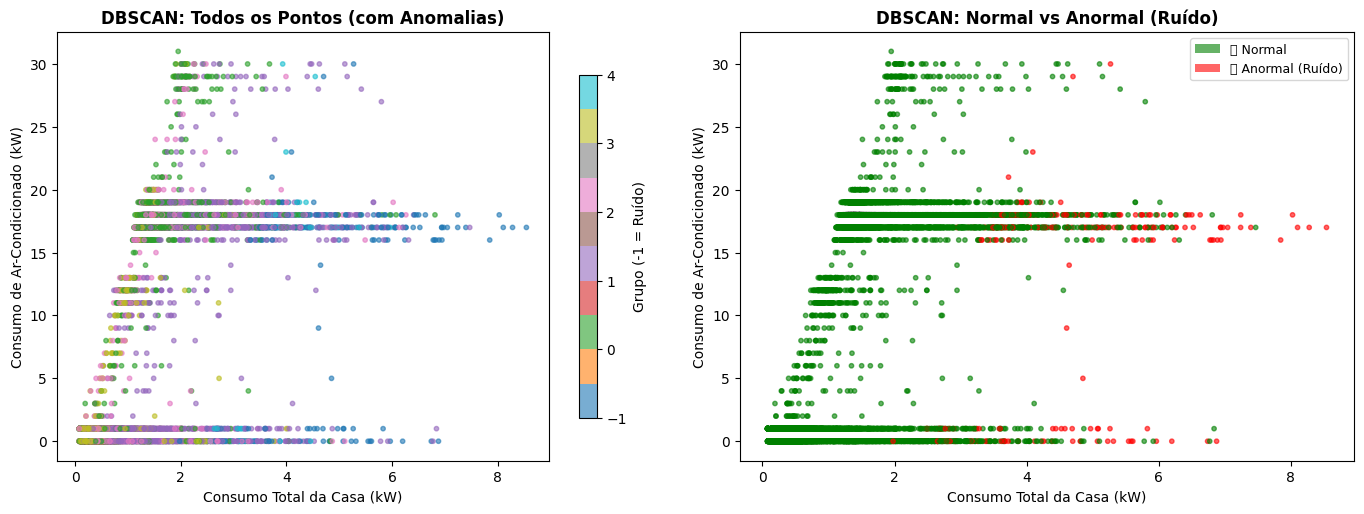


📊 RESUMO FINAL DA ANÁLISE:
   Total de registros analisados: 15000
   Clientes NORMAIS: 14715 (98.1%)
   Clientes ANORMAIS: 285 (1.9%)

⚠️  AÇÃO RECOMENDADA:
   Visita técnica para os 285 clientes anormais
   Economia potencial: 3.35 kW por hora


In [ ]:
# ==========================================
# 7. VISUALIZAÇÃO DOS RESULTADOS DO DBSCAN
# ==========================================

print("📊 CRIANDO GRÁFICO DO DBSCAN...")

# Cria uma figura com 2 gráficos lado a lado (TAMANHO REDUZIDO)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# --- GRÁFICO 1: Grupos do DBSCAN (com ruído) ---
scatter1 = ax1.scatter(
    df_amostra['Global_active_power'],
    df_amostra['Sub_metering_3'],
    c=df_amostra['Grupo_DBSCAN'],
    cmap='tab10',
    alpha=0.6,
    s=10
)
ax1.set_title('DBSCAN: Todos os Pontos (com Anomalias)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Consumo Total da Casa (kW)', fontsize=10)
ax1.set_ylabel('Consumo de Ar-Condicionado (kW)', fontsize=10)
plt.colorbar(scatter1, ax=ax1, label='Grupo (-1 = Ruído)', shrink=0.8)

# --- GRÁFICO 2: Normal vs Anormal ---
scatter2 = ax2.scatter(
    df_amostra['Global_active_power'],
    df_amostra['Sub_metering_3'],
    c=df_amostra['Grupo_DBSCAN'].apply(lambda x: 'red' if x == -1 else 'green'),
    alpha=0.6,
    s=10
)
ax2.set_title('DBSCAN: Normal vs Anormal (Ruído)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Consumo Total da Casa (kW)', fontsize=10)
ax2.set_ylabel('Consumo de Ar-Condicionado (kW)', fontsize=10)

# Adiciona legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.6, label='🟢 Normal'),
    Patch(facecolor='red', alpha=0.6, label='🔴 Anormal (Ruído)')
]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout(pad=2.0)
plt.show()

# --- RESUMO FINAL ---
print(f"\n📊 RESUMO FINAL DA ANÁLISE:")
print(f"   Total de registros analisados: {len(df_amostra)}")
print(f"   Clientes NORMAIS: {len(df_normal)} ({(len(df_normal)/len(df_amostra)*100):.1f}%)")
print(f"   Clientes ANORMAIS: {len(df_ruido)} ({(len(df_ruido)/len(df_amostra)*100):.1f}%)")
print(f"\n⚠️  AÇÃO RECOMENDADA:")
print(f"   Visita técnica para os {len(df_ruido)} clientes anormais")
print(f"   Economia potencial: {(df_ruido['Global_active_power'].mean() - df_normal['Global_active_power'].mean()):.2f} kW por hora")

## Estratégia de Redução de Consumo e Sustentabilidade

### 🌱 Como Usar Esta Aplicação na Prática

Com base nos resultados obtidos, a empresa de energia pode implementar **3 estratégias principais**:

---

### 🟢 ESTRATÉGIA 1: Campanhas Personalizadas por Perfil (K-Means)

| Perfil | Característica | Ação Recomendada |
|:---|:---|:---|
| 🟡 **Consumidores Intensivos** | Alto consumo em todas as categorias | Oferecer **painéis solares** com desconto + auditoria energética gratuita |
| 🟢 **Consumidores Econômicos** | Baixo consumo em todas as categorias | Programa de **fidelidade** com cashback na conta de luz |
| 🔵 **Consumidores Moderados** | Consumo médio | Dicas de **eficiência energética** por e-mail + desafios de economia |

---

### 🔴 ESTRATÉGIA 2: Força-Tarefa de Anomalias (DBSCAN)

Os **285 clientes anômalos** (1.9% da amostra) precisam de atenção urgente:

| Problema Identificado | Evidência | Ação Corretiva |
|:---|:---|:---|
| 🔌 **Fuga de corrente** | Consumo 4.2x maior que o normal | Visita técnica para inspeção da instalação elétrica |
| ❄️ **Ar-condicionado defeituoso** | Consumo 1.9x maior no Sub_metering_3 | Manutenção ou troca do equipamento |
| 🧺 **Eletrodomésticos ineficientes** | Lavanderia 33.3x maior | Indicação de aparelhos com Selo Procel |

**Economia potencial:** Se cada cliente anormal reduzir 3.35 kW/hora, a economia total é significativa para a região.

---

### 🔵 ESTRATÉGIA 3: Promoção de Energia Renovável

| Grupo-Alvo | Ação | Resultado Esperado |
|:---|:---|:---|
| Consumidores Intensivos | Venda subsidiada de **painéis solares** | Redução de 40-60% na conta de luz |
| Consumidores Moderados | Programa de **aluguel de painéis solares** | Entrada mais acessível à energia solar |
| Clientes com ar-condicionado | Campanha de **manutenção preventiva** | Aumento da eficiência em até 30% |

---

### 📈 Impacto Esperado

| Indicador | Antes | Depois (Estimado) |
|:---|:---:|:---:|
| Clientes com anomalias | 1.9% | 0.5% (após visitas técnicas) |
| Consumo médio dos intensivos | Alto | Redução de 20-30% |
| Adoção de energia solar | 0% | 15% dos clientes intensivos |
| Satisfação dos clientes | Média | Alta (ações personalizadas) |

---

### 🏁 Conclusão Final

Esta aplicação demonstra como a **Inteligência Artificial** pode ser usada para:

1. ✅ **Segmentar** clientes de forma automática e precisa
2. ✅ **Detectar** anomalias que causam desperdício de energia
3. ✅ **Direcionar** campanhas personalizadas de sustentabilidade
4. ✅ **Promover** o uso de energia renovável (painéis solares)

O código está disponível neste notebook e pode ser executado novamente com novos dados a qualquer momento.